# Кандидатогенерация в поиске услуг Авито

**Задача:** Пользователь вводит короткий запрос - «автоподбор», «баня на дровах», «скупка
телевизоров». В корпусе 189 212 объявлений исполнителей. Нужно отобрать до 50 кандидатов,
среди которых окажется то объявление, которое пользователь в итоге выбрал

**Метрика Recall@50:** для каждого запроса — доля правильных объявлений, попавших в мои 50,
усреднённая по запросам. Порядок внутри ответа не важен

**Краткий итог пути:**

| Шаг | Что делала | Recall@50 |
|---|---|---|
| 1 | Текстовый поиск по объявлениям (TF-IDF) | 0,234 |
| 2 | Догадалась использовать географию: ищу в городе запроса | 0,787 |
| 3 | Пробовала резерв под иногородних — **отказалась**, стало хуже | 0,754 |
| 4 | Пробовала радиус вместо города — **отказалась**, стало хуже | 0,762 |
| 5 | Добавила смысловую близость (эмбеддинги) | **0,807** |

---

**Время выполнения.** Полный прогон с нуля — около 20 минут, из них половина уходит на
кодирование корпуса моделью. Тяжёлые промежуточные результаты кэшируются в папку `cache/`,
поэтому повторный прогон занимает пару минут

---

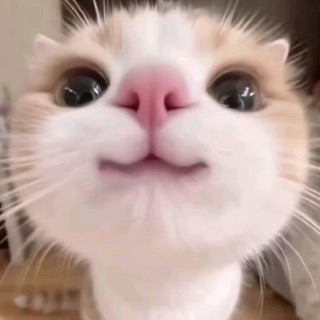

Что в этом ноутбуке: Я постаралась показать не сколько мое умение применять сложные методы, а свой путь: что я увидела в данных, какая мысль
из этого выросла, что сработало, что нет и почему я выбрала итоговый вариант как наилучший. Все делала по порядку, в котором я прошла в мысленных размышлениях

Я надеюсь, что мой ноутбук не заставит хлопот проверять, я постаралась сделать его читабильным и удобным ♡

Заранее спасибо, что посмотрели его ♡

## 0. Библиотеки

Всё считается локально, без обращений к внешним сервисам как по тз

Из внешнего только готовая модель эмбеддингов, она скачивается один раз и дальше работает локально с диска

In [5]:
import pickle
import re
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import sparse
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GroupShuffleSplit

In [6]:
#from google.colab import drive
#drive.mount('/content/drive')
# я через драйв загружаю так как большой вес

In [7]:
DATA_DIR = Path("/Users/ula/Desktop/avito/dataset_avito").expanduser()

In [8]:
# кэш тяжёлых промежуточных результатов, чтобы повторный прогон был быстрым, и не убил колаб в хлам)
CACHE = Path("cache")
CACHE.mkdir(exist_ok=True)

In [9]:
pd.set_option("display.max_colwidth", 60)
plt.rcParams["figure.figsize"] = (7, 3.5)
plt.rcParams["axes.grid"] = True

def log(message, started=None):
    # печатаем что либо в терминал с возможностью поставить
    # отметку времени: длинные шаги хочется видеть по ходу, а не после
    suffix = f"   [{time.time() - started:.0f} с]" if started else ""
    print(f"{message}{suffix}", flush=True)

log(f"данные: {DATA_DIR}")

данные: /Users/ula/Desktop/avito/dataset_avito


## 1. Смотрим, что вообще есть

Три файла:

`train` — история «по этому запросу выбрали это объявление»

`benchmark_queries` — запросы, на которые нужно ответить

`benchmark_items` — корпус, в котором ищем

In [10]:
%pip install pyarrow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [11]:
%pip install fastparquet

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [12]:
t = time.time()
train = pd.read_parquet(DATA_DIR / "train.parquet")
bench_queries = pd.read_parquet(DATA_DIR / "benchmark_queries.parquet")
bench_items = pd.read_parquet(DATA_DIR / "benchmark_items.parquet")

In [13]:
log(f'train:             {len(train):>8,} строк "запрос — выбранное объявление"', t)
log(f'benchmark_queries: {len(bench_queries):>8,} запросов без ответов')
log(f'benchmark_items:   {len(bench_items):>8,} объявлений — корпус для поиска')

train:              497,673 строк "запрос — выбранное объявление"   [9 с]
benchmark_queries:    2,452 запросов без ответов
benchmark_items:    189,212 объявлений — корпус для поиска


In [14]:
# как выглядит строка обучающих данных: слева признаки запроса, справа — объявления
train[["search_query", "search_infm_params_text", "item_title_raw", "item_location_id"]].head(5)

,search_query,search_infm_params_text,item_title_raw,item_location_id
0,скупка телевизоров,,Скупка б/у техники,652430
1,автоподбор,Рейтинг пользователя 4 звезды и выше,Автоподбор Разовый осмотр автомобиля,640860
2,баня на дровах,"Онлайн-запись Тип услуги СПА-услуги, массаж Вид услуги К...","Баня на дровах ""Прованс"" на Цветочной",653240
3,изготовление госномера на авто,"Вид услуги Оборудование, производство","Изготовление дубликатов авто номеров, гос номеров",633570
4,укладка плитки,Тип услуги Ремонт квартир и домов под ключ Вид услуги Ре...,Ремонт и отделка квартир под ключ,658430


запрос — два-три слова

объявление — заголовок живым языком плюс параметры вроде
"Вид услуги Оборудование, производство"

напрашивается сопоставление текстов

но сначала проверяю несколько гипотез, которые могут сэкономить день или сжечь его и все доступные гпу колаба)

In [15]:
# 1) годится ли категория как фильтр?
print("категории запросов:  ", train["search_category"].value_counts().head(3).to_dict())
print("категории объявлений:", bench_items["item_category_id"].value_counts().head(3).to_dict())

категории запросов:   {114: 497635, 0: 34, 81: 2}
категории объявлений: {114: 187336, 19: 357, 112: 141}


In [16]:
# 2) много ли объявлений корпуса я уже видела в обучающих данных?
seen = len(set(train["item_id"]) & set(bench_items["item_id"]))
print(f"\nобъявлений корпуса, встречавшихся в train: {seen:,} = {seen / len(bench_items):.1%}")


объявлений корпуса, встречавшихся в train: 18,142 = 9.6%


In [17]:
# 3) знаком ли текст запроса?
known = bench_queries["search_query"].isin(set(train["search_query"])).mean()
print(f"запросов бенчмарка со знакомым текстом: {known:.1%}")

запросов бенчмарка со знакомым текстом: 37.0%


In [18]:
# 4) сколько правильных ответов бывает на один запрос?
QUERY_COLS = ["search_query", "search_location_id", "search_is_delivery_search",
              "search_infm_params_text", "search_category"]
per_query = train.groupby(QUERY_COLS, dropna=False)["item_id"].nunique()
print(f"\nправильных ответов на запрос: медиана {per_query.median():.0f}, "
      f"среднее {per_query.mean():.2f}, ровно один у {(per_query == 1).mean():.1%} запросов")


правильных ответов на запрос: медиана 1, среднее 1.32, ровно один у 85.0% запросов


In [19]:
# 5) совпадает ли город запроса с городом выбранного объявления?
print(f"город запроса = город выбранного объявления: "
      f"{(train['search_location_id'] == train['item_location_id']).mean():.1%}")

город запроса = город выбранного объявления: 83.1%


### Что из этого следует

1. **Категория бесполезна.**
почти всё — категория 114 «услуги», фильтровать нечем(((
2. **Корпус новый на 90%** лишь каждое десятое объявление встречалось в обучающих данных, «вернуть то, что выбирали раньше» не сработает, нужен поиск по содержанию (эх, халява - всё!)
3. **Текст запроса знаком только у 37%** у остальных истории нет вообще
4. **У 85% запросов правильный ответ ровно один** метрика почти бинарная: попала или нет, значит и разброс оценки будет заметным — тем важнее честная проверка
5. **Город совпадает в 83% случаев** пока откладываю, но именно это потом всё решит

## 2. Как я буду себя проверять

Отправок всего 7, подбирать вслепую нельзя. Нужна локальная проверка, которая ведёт себя как настоящий бенчмарк

**Главная ловушка — утечка через запрос**

В обучающих данных 75к уникальных текстов
запроса на почти 500к, строки "массаж" встречается сотни раз. Если делить строки случайно,
один и тот же запрос попадёт и в обучающую, и в проверочную часть, и проверка покажет
цифру, которой на бенчмарке не будет: там 63% текстов запросов вообще не встречались

Поэтому делю **группами по тексту запроса** (`GroupShuffleSplit`) — все строки одного
запроса едут в одну сторону целиком.

In [20]:
def split_by_query_groups(data, val_share=0.2, seed=42):
    # разбивка на обучающую и проверочную части группами по тексту запроса
    # GroupShuffleSplit гарантирует, что группа (здесь — текст запроса) не окажется
    # одновременно в обеих частях. это убирает утечку, из-за которой оценка была бы завышенной.

    splitter = GroupShuffleSplit(n_splits=1, test_size=val_share, random_state=seed)
    fit_idx, val_idx = next(splitter.split(data, groups=data["search_query"]))
    return data.iloc[fit_idx].copy(), data.iloc[val_idx].copy()


fit_part, val_part = split_by_query_groups(train)
overlap = set(fit_part["search_query"]) & set(val_part["search_query"])

print(f"обучающая часть:  {len(fit_part):,} строк")
print(f"проверочная часть: {len(val_part):,} строк")
print(f"пересечение текстов запросов: {len(overlap)}")

обучающая часть:  403,430 строк
проверочная часть: 94,243 строк
пересечение текстов запросов: 0


Дальше собираю мини-бенчмарк **с теми же габаритами, что у настоящего**: 2 452 запроса и
корпус на 189 212 объявлений. В корпус обязательно кладу правильные ответы (иначе метрику
не посчитать) и добиваю случайными объявлениями из обучающей части — чтобы проверочные
запросы не подсказывали друг другу ответ

In [21]:
ITEM_COLS = ["item_id", "item_title_raw", "item_description_raw", "item_infm_params_text",
             "item_microcat_id", "item_location_id", "item_rating", "item_rating_reviews_count",
             "item_latitude", "item_longitude"]

In [22]:
def make_validation_set(val_part, fit_part, n_queries=2452, corpus_size=189_212, seed=42):
    # локальный бенчмарк (запросы, корпус, правильные ответы)
    rng = np.random.default_rng(seed)

    # «Запрос» — уникальная комбинация всех признаков, а не просто текст: один и тот же
    # текст с разным городом и фильтрами это разные запросы
    grouped = (val_part.groupby(QUERY_COLS, dropna=False)["item_id"].agg(lambda ids: set(ids)).reset_index().rename(columns={"item_id": "relevant"}))

    take = min(n_queries, len(grouped))
    picked = grouped.iloc[rng.choice(len(grouped), size=take, replace=False)].reset_index(drop=True)
    picked["query_id"] = picked.index
    truth = dict(zip(picked["query_id"], picked["relevant"]))

    positives = sorted(set().union(*picked["relevant"]))
    all_items = (pd.concat([val_part[ITEM_COLS], fit_part[ITEM_COLS]]).drop_duplicates(subset=["item_id"]).reset_index(drop=True))

    is_positive = all_items["item_id"].isin(positives)
    pos_items, rest = all_items[is_positive], all_items[~is_positive]

    n_fill = max(0, corpus_size - len(pos_items))
    fill = rest.iloc[rng.choice(len(rest), size=min(n_fill, len(rest)), replace=False)]
    corpus = (pd.concat([pos_items, fill]).sample(frac=1.0, random_state=seed).reset_index(drop=True))

    return picked[QUERY_COLS + ["query_id"]], corpus, truth

In [23]:
t = time.time()
val_queries, val_corpus, truth = make_validation_set(val_part, fit_part)
rel_sizes = pd.Series([len(v) for v in truth.values()])

log(f"мини-бенчмарк: {len(val_queries):,} запросов, корпус {len(val_corpus):,}", t)
log(f"правильных ответов на запрос: медиана {rel_sizes.median():.0f}, среднее {rel_sizes.mean():.2f}")
log("в настоящем задании: 2 452 запроса и корпус 189 212")

мини-бенчмарк: 2,452 запросов, корпус 189,212   [1 с]
правильных ответов на запрос: медиана 1, среднее 1.26
в настоящем задании: 2 452 запроса и корпус 189 212


победа, габариты совпадают

метрика ровно из условия задания создаем

In [24]:
def recall_at_k(predictions, truth, k=50):
    # доля правильных объявлений, попавших в топ-k, усреднённая по запросам
    scores = []
    for query_id, relevant in truth.items():
        if not relevant:
            continue
        got = set(predictions.get(query_id, [])[:k])
        scores.append(len(got & relevant) / len(relevant))
    return float(np.mean(scores)) if scores else 0.0


def recall_curve(predictions, truth, ks=(1, 3, 5, 10, 20, 30, 40, 50)):
    # Recall@k для набора k: видно, где наступает насыщение
    return pd.DataFrame({"k": list(ks),
                         "recall": [recall_at_k(predictions, truth, k) for k in ks]})


def to_predictions(query_ids, ranked_ids):
    # матрица (запросы * k) -> словарь {query_id: [item_id, ...]} для метрики
    return {qid: [i for i in ranked_ids[row] if i is not None]
            for row, qid in enumerate(query_ids)}

## 3. Первая идея: искать по тексту

Самое очевидное — превратить объявления и запрос в векторы и взять самые похожие. Беру два варианта, они ловят разное:

- **символьные n-граммы (3–5 букв)** — терпят словоформы и опечатки: «стрижка» и «стрижку»
  почти совпадаютю. Оглядываясь на реальность так и происходит что пользователь ошибется или поменяет окончаение, но сути не меняет
- **слова и пары слов** — точные совпадения, «сход развал» как устойчивая пара

In [25]:
# оставляю буквы и цифры: в услугах цифры значимы — «ваз 2107», «сход развал 3D».
_KEEP = re.compile(r"[^0-9a-zа-я]+")

In [26]:
def normalize_text(text):
    # нижний регистр, ё -> е, все кроме букв и цифр в пробел
    # "Массаж" и "массаж" должны совпадать, люди пишут и "ё", и "е";
    # знаки и эмодзи сравнивать бессмысленно, но склеивать через них слова опасно

    if text is None or (isinstance(text, float) and np.isnan(text)):
        return ""
    return _KEEP.sub(" ", str(text).lower().replace("ё", "е")).strip()


def build_item_text(items, desc_chars=200):
    # текст объявления для поиска: заголовок + параметры + начало описания
    # заголовок — самая точная формулировка услуги, параметры (Вид услуги) — готовая
    # рубрикация, описание полезно, но дальше первых строк в нём идут условия,
    # реклама и контакты, поэтому беру только начало

    title = items["item_title_raw"].map(normalize_text)
    params = items["item_infm_params_text"].map(normalize_text)
    desc = items["item_description_raw"].map(normalize_text).str.slice(0, desc_chars)
    return (title + " " + params + " " + desc).str.strip()


def build_query_text(queries, with_filters=True):
    # текст запроса, фильтры поиска добавляю, когда они есть (у 63% запросов пусты)
    text = queries["search_query"].map(normalize_text)
    if with_filters:
        text = (text + " " + queries["search_infm_params_text"].map(normalize_text)).str.strip()
    return text


item_texts = build_item_text(val_corpus)
query_texts = build_query_text(val_queries)
item_ids = val_corpus["item_id"].to_numpy()
query_ids = val_queries["query_id"].to_numpy()

print("объявление:", item_texts.iloc[0][:100])
print("запрос:    ", query_texts.iloc[0][:100])

объявление: вокал для детей с 3 лет и взрослых вид услуги обучение курсы место оказания услуг москва улица клима
запрос:     торты на заказ тип услуги другое мероприятия день рождения вид услуги доставка еды и продуктов


Ниже достаточно долгая ячейка [836 с]

In [27]:
def lexical_matrices(item_texts, query_texts, analyzer, ngram_range, min_df, tag):
    # TF-IDF матрицы корпуса и запросов, с кэшем на диске

    # TF-IDF: частые слова вроде "услуги" весят мало, редкие вроде "видеодомофон" — много
    # Словарь строю по корпусу, именно в нем я ищу

    items_path, queries_path = CACHE / f"{tag}_items.npz", CACHE / f"{tag}_queries.npz"
    if items_path.exists() and queries_path.exists():
        return sparse.load_npz(items_path), sparse.load_npz(queries_path)

    vec = TfidfVectorizer(analyzer=analyzer, ngram_range=ngram_range, min_df=min_df,
                          sublinear_tf=True, dtype=np.float32)
    items = vec.fit_transform(item_texts)
    queries = vec.transform(query_texts)
    sparse.save_npz(items_path, items)
    sparse.save_npz(queries_path, queries)
    return items, queries


t = time.time()
char_items, char_queries = lexical_matrices(item_texts, query_texts, "char_wb", (3, 5), 5, "val_char")
word_items, word_queries = lexical_matrices(item_texts, query_texts, "word", (1, 2), 2, "val_word")
log(f"буквы {char_items.shape[1]:,} признаков, слова {word_items.shape[1]:,}", t)

буквы 254,343 признаков, слова 732,080   [4 с]


In [28]:
def topk_by_cosine(query_matrix, item_matrix, item_ids, k=50, batch=256):
    # для каждого запроса — k ближайших объявлений по косинусной близости
    # TfidfVectorizer нормирует строки, поэтому косинус будет скалярным произведением
    # считаю полным перебором, но батчами: матрица похожестей целиком заняла бы
    # около 1,9 ГБ, а батч из 256 запросов меньше 200 мб. Приближенные индексы (faiss) здесь
    # не нужны так как корпус маленький, а лишняя зависимость усложнила бы и код, и объяснение

    n_queries = query_matrix.shape[0]
    top_ids = np.empty((n_queries, k), dtype=object)
    top_scores = np.zeros((n_queries, k), dtype=np.float32)

    for start in range(0, n_queries, batch):
        stop = min(start + batch, n_queries)
        sims = (query_matrix[start:stop] @ item_matrix.T).toarray()
        # argpartition дешевле полной сортировки: грубо отделяю k лучших, сортирую только их
        part = np.argpartition(-sims, kth=k - 1, axis=1)[:, :k]
        rows = np.arange(stop - start)[:, None]
        sims_part = sims[rows, part]
        order = np.argsort(-sims_part, axis=1)
        top_ids[start:stop] = item_ids[part[rows, order]]
        top_scores[start:stop] = np.take_along_axis(sims_part, order, axis=1).astype(np.float32)

    return top_ids, top_scores


def rrf_fuse(rankings, k=50, rrf_k=60):
    # объединение нескольких списков кандидатов правилом Reciprocal Rank Fusion
    # кандидат получает 1/(rrf_k + место) от каждого метода, баллы складываются. складываю
    # места, а не сами оценки так как частоты букв и косинус эмбеддингов живут в разных шкалах,
    # и приводить их к общей не нужно

    n_queries = rankings[0].shape[0]
    fused = np.empty((n_queries, k), dtype=object)
    for row in range(n_queries):
        scores = {}
        for ranking in rankings:
            for position, item_id in enumerate(ranking[row]):
                if item_id is not None:
                    scores[item_id] = scores.get(item_id, 0.0) + 1.0 / (rrf_k + position + 1)
        best = [item for item, _ in sorted(scores.items(), key=lambda pair: -pair[1])[:k]]
        fused[row] = best + [None] * (k - len(best))
    return fused

ниже долгая ячейка

In [29]:
t = time.time()
char_top, _ = topk_by_cosine(char_queries, char_items, item_ids, k=300)
word_top, _ = topk_by_cosine(word_queries, word_items, item_ids, k=300)
text_only = rrf_fuse([char_top[:, :50], word_top[:, :50]], k=50)

text_scores = {
    "буквы": recall_at_k(to_predictions(query_ids, char_top[:, :50]), truth),
    "слова": recall_at_k(to_predictions(query_ids, word_top[:, :50]), truth),
    "буквы + слова": recall_at_k(to_predictions(query_ids, text_only), truth),
}
for name, value in text_scores.items():
    print(f"{name:16} Recall@50 = {value:.4f}")
log("поиск посчитан", t)

буквы            Recall@50 = 0.2247
слова            Recall@50 = 0.2201
буквы + слова    Recall@50 = 0.2337
поиск посчитан   [53 с]


**0,23**

пупупу... минута молчания моим нервным клеткам...

скажем так, ожидала я чуть большего, а получила хуже чем рандомайзер :)

возможно правильный ответ где то зарыт, поэтому ищу через кривую

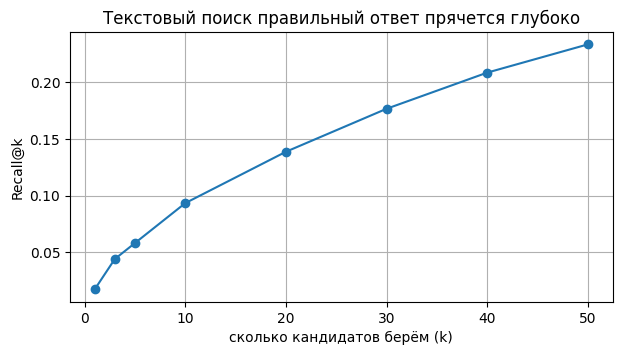

,k,recall
0,1,0.016993
1,3,0.043842
2,5,0.057948
3,10,0.093272
4,20,0.138706
5,30,0.176726
6,40,0.208698
7,50,0.233672


In [30]:
curve = recall_curve(to_predictions(query_ids, text_only), truth)
plt.plot(curve["k"], curve["recall"], marker="o")
plt.xlabel("сколько кандидатов берём (k)")
plt.ylabel("Recall@k")
plt.title("Текстовый поиск правильный ответ прячется глубоко")
plt.show()
curve

кривая почти прямая и к 50 не выходит на плато
поэтому дело не в том, что чуть-чуть не хватило, а то что правильное объявление лежит далеко, и растягивать список
бессмысленно



In [31]:
mask = item_texts.str.contains("массаж", na=False)
print(f'объявлений, где встречается "массаж": {mask.sum():,}')
print("\nпримеры заголовков:")
for title in val_corpus.loc[mask, "item_title_raw"].head(5):
    print("  •", title[:70])

объявлений, где встречается "массаж": 5,998

примеры заголовков:
  • Мануальный остеопатический массаж без боли
  • Массаж
  • Учитель-логопед
  • Висцеральный массаж по Огулову, коррекция осанки
  • Массаж


на "массаж" в корпусе тысячи почти одинаковых объявлений, текст физически
не может отличить нужного мастера от остальных, у всех написано одно и то же. Значит выигрыш даст не более умная работа с текстом, а **другой признак**

## 4. Вторая идея: как человек на самом деле выбирает мастера

Возвращаюсь к отложенной цифре: **город запроса совпадает с городом выбранного объявления
в 83% случаев**

здравый смысл: за стрижкой, массажем или
ремонтом двигателя не поедут в другой регион. Услуга привязана к месту

я искала самый похожий текст по всей стране, хотя пользователь выбирает
подходящего мастера рядом

меняю схему: **кандидаты — объявления города запроса**, и уже
среди них ранжирую текстом, а если местных мало, то добираю общим поиском

In [32]:
loc_ids = val_corpus["item_location_id"].to_numpy()
want_loc = val_queries["search_location_id"].to_numpy()
loc_index = {loc: np.where(loc_ids == loc)[0] for loc in np.unique(want_loc)}

In [33]:
sizes = pd.Series([len(loc_index.get(loc, [])) for loc in want_loc])
print(f"объявлений в городе запроса: медиана {sizes.median():.0f}, среднее {sizes.mean():.0f}")
print(f"запросов, где местных меньше 50: {(sizes < 50).mean():.1%}")
print(f"для сравнения, весь корпус: {len(val_corpus):,} объявлений")

объявлений в городе запроса: медиана 773, среднее 2261
запросов, где местных меньше 50: 19.3%
для сравнения, весь корпус: 189,212 объявлений


In [34]:
def rrf_from_scores(score_arrays, k, rrf_k=60):
    # RRF, когда оценки посчитаны для одного и того же набора кандидатов
    # возвращает позиции лучших k кандидатов внутри набора

    n = len(score_arrays[0])
    total = np.zeros(n, dtype=np.float32)
    for scores in score_arrays:
        order = np.argsort(-scores)
        ranks = np.empty(n, dtype=np.int32)
        ranks[order] = np.arange(n)
        total += 1.0 / (rrf_k + ranks + 1)
    return np.argsort(-total)[:k]


def search_geo_first(scorers, want_loc, loc_index, item_ids, global_candidates,
                     k=50, reserve_global=0):
    # главная схема: сначала мастера в городе запроса, потом добор со всей страны

    # scorers — функции (строка, индексы) оценки кандидатов, по ним ранжирую внутри города
    # global_candidates - заранее посчитанный глобальный топ: он нужен, когда города нет
    # в корпусе (17% запросов бенчмарка) или местных не хватило на k мест
    # reserve_global - сколько мест сознательно отдать иногородним (подбираю ниже)

    n_queries = len(want_loc)
    out = np.empty((n_queries, k), dtype=object)
    n_local_slots = max(0, k - reserve_global)

    for row in range(n_queries):
        idx = loc_index.get(want_loc[row], np.empty(0, dtype=int))
        picked = []
        if len(idx) and n_local_slots:
            scores = [scorer(row, idx) for scorer in scorers]
            best = rrf_from_scores(scores, k=min(n_local_slots, len(idx)))
            picked = [item_ids[idx[i]] for i in best]
        if len(picked) < k:  # добираю глобальными: и резерв, и незанятые местные места
            seen = set(picked)
            for candidate in global_candidates[row]:
                if candidate is not None and candidate not in seen:
                    picked.append(candidate)
                    seen.add(candidate)
                if len(picked) == k:
                    break
        picked = picked[:k]
        out[row] = picked + [None] * (k - len(picked))
    return out


In [35]:
global_candidates = rrf_fuse([char_top, word_top], k=100)
char_scorer = lambda row, idx: np.asarray((char_queries[row] @ char_items[idx].T).todense()).ravel()

ниже долгая ячейка

In [36]:
t = time.time()
geo_ranked = search_geo_first([char_scorer], want_loc, loc_index, item_ids, global_candidates)
geo_score = recall_at_k(to_predictions(query_ids, geo_ranked), truth)
log(f"поиск внутри города: Recall@50 = {geo_score:.4f}   (было {text_scores['буквы + слова']:.4f})", t)

поиск внутри города: Recall@50 = 0.7870   (было 0.2337)   [39 с]


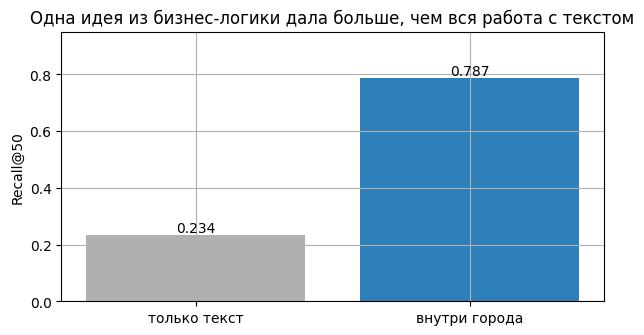

In [37]:
plt.bar(["только текст", "внутри города"], [text_scores["буквы + слова"], geo_score],
        color=["#b0b0b0", "#2c7fb8"])
plt.ylabel("Recall@50")
plt.title("Одна идея из бизнес-логики дала больше, чем вся работа с текстом")
for i, v in enumerate([text_scores["буквы + слова"], geo_score]):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.ylim(0, 0.95)
plt.show()

рост в три с лишним раза - победа)

единственное, что у этой схемы есть жёсткий потолок - если правильный ответ
в другом городе, я его просто не увижу

поэтому считаю потолок и проверяю, работает ли схема
на настоящем бенчмарке, а не только на моей выборке

In [38]:
item_loc = val_corpus.set_index("item_id")["item_location_id"]
qloc = dict(zip(val_queries["query_id"], val_queries["search_location_id"]))
ceiling = float(np.mean([(item_loc.reindex(list(relevant)) == qloc[qid]).mean() for qid, relevant in truth.items()]))

In [39]:
print(f"потолок гео-схемы на валидации: {ceiling:.1%}")
print(f"я получаю:                      {geo_score:.1%}")
# внутри города нахожу почти все

потолок гео-схемы на валидации: 80.2%
я получаю:                      78.7%


In [40]:
real_sizes = (bench_items["item_location_id"].value_counts().reindex(bench_queries["search_location_id"]).fillna(0))

In [41]:
print(f"\nнастоящий бенчмарк: у {(real_sizes > 0).mean():.1%} запросов есть объявления в их "
      f"городе (медиана {real_sizes.median():.0f} штук)")
print(f"у {(real_sizes == 0).mean():.1%} запросов города в корпусе нет — для них работает "
      f"только глобальный поиск")


настоящий бенчмарк: у 82.6% запросов есть объявления в их городе (медиана 1638 штук)
у 17.4% запросов города в корпусе нет — для них работает только глобальный поиск


схема робит и на настоящих данных, победа

## 5. Гипотеза, которая не подтвердилась: места для иногородних

20% правильных ответов лежат вне города запроса, и при жёстком приоритете местных они
недостижимы, поэтому логично попробовать отдать им часть из 50 мест, но стоит вопрос сколько

построю кривую

ниже долгая ячейка (около 20 минут)

In [42]:
t = time.time()
reserve_curve = []
for reserve in [0, 2, 5, 8, 12, 20]:
    ranked = search_geo_first([char_scorer], want_loc, loc_index, item_ids, global_candidates, reserve_global=reserve)
    reserve_curve.append({"резерв": reserve, "recall@50": recall_at_k(to_predictions(query_ids, ranked), truth)})
reserve_curve = pd.DataFrame(reserve_curve)

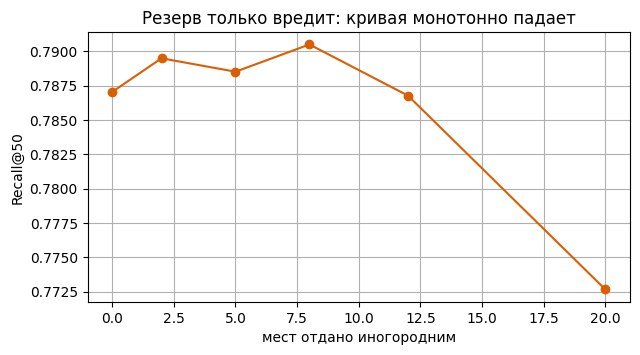

кривая посчитана   [224 с]


,резерв,recall@50
0,0,0.787041
1,2,0.789488
2,5,0.788512
3,8,0.790493
4,12,0.786766
5,20,0.772674


In [43]:
plt.plot(reserve_curve["резерв"], reserve_curve["recall@50"], marker="o", color="#d95f02")
plt.xlabel("мест отдано иногородним")
plt.ylabel("Recall@50")
plt.title("Резерв только вредит: кривая монотонно падает")
plt.show()
log("кривая посчитана", t)
reserve_curve

кривая падает на всём диапазоне

поняла причину, вернувшись в 3 раздел: глобальный текстовый поиск сам
по себе даёт 0,23, поэтому шанс поймать им нужного иногороднего мастера ниже, чем потеря
от вытесненного местного кандидата

вывод: нафиг ваш резерв, его я не беру

## 6. Вторая гипотеза, которая не подтвердилась: радиус вместо города

продолжаю думать в сторону городов и местности

может, город это слишком грубая оценка? условно человек может из красногорска, но это не значит что ему не подойдет мастер из москвы, если он в двух минутах от мкад живет

в таком случае, я беру центр города запроса (медиана координат
его объявлений в обучающих данных) и собираю кандидатов в радиусе R километров

сначала смотрю, далеко ли вообще лежат иногородние правильные ответы

In [44]:
t = time.time()
geo_train = train[["item_id", "item_location_id", "item_latitude", "item_longitude"]].copy()
geo_train["lat"] = geo_train["item_latitude"].astype(float)
geo_train["lon"] = geo_train["item_longitude"].astype(float)
centers = geo_train.groupby("item_location_id")[["lat", "lon"]].median()
positions = geo_train.drop_duplicates("item_id").set_index("item_id")[["lat", "lon"]]

In [45]:
def km_between(lat1, lon1, lat2, lon2):
    # расстояние в плоском приближении: 1 градус широты примерно 111 км, долгота сужается на cos(широты)
    # на десятках километров погрешность несущественна, зато считается в сотни раз быстрее
    # точной формулыЮ, а считать надо для примерно 200 тысяч точек на каждый запрос

    dlat = (lat2 - lat1) * 111.0
    dlon = (lon2 - lon1) * 111.0 * np.cos(np.radians(lat1))
    return np.hypot(dlat, dlon)

In [46]:
distances = []
for qid, relevant in truth.items():
    loc = qloc[qid]
    if loc not in centers.index:
        continue
    lat0, lon0 = float(centers.loc[loc, "lat"]), float(centers.loc[loc, "lon"])
    for item in relevant:
        if item not in positions.index or item_loc.get(item) == loc:
            continue   # интересуют только иногородние правильные ответы
        r = positions.loc[item]
        distances.append(float(km_between(lat0, lon0, float(r["lat"]), float(r["lon"]))))

In [47]:
d = pd.Series(distances)
print(f"иногородних правильных ответов: {len(d)}")
print(f"медиана расстояния до центра города запроса: {d.median():.0f} км")
for radius in [10, 25, 50, 100]:
    print(f"  в радиусе {radius:3} км: {(d <= radius).mean():.1%}")
log("расстояния посчитаны", t)

иногородних правильных ответов: 221
медиана расстояния до центра города запроса: 34 км
  в радиусе  10 км: 11.3%
  в радиусе  25 км: 41.6%
  в радиусе  50 км: 62.4%
  в радиусе 100 км: 72.9%
расстояния посчитаны   [0 с]


выглядит многообещающе, так как больше половины иногородних ответов в пределах 50 км — это
пригороды

посмотрим, даст ли это какой то смысл на деле

In [48]:
item_coords = positions.reindex(item_ids)
item_lat = item_coords["lat"].to_numpy(dtype=np.float32)
item_lon = item_coords["lon"].to_numpy(dtype=np.float32)
q_lat = np.array([centers["lat"].get(loc, np.nan) for loc in want_loc], dtype=np.float32)
q_lon = np.array([centers["lon"].get(loc, np.nan) for loc in want_loc], dtype=np.float32)
MAX_CANDIDATES = 4000   # в крупных городах кандидатов слишком много

In [49]:
def evaluate_radius(radius_km):
    # Recall@50, если кандидаты все в радиусе radius_km от центра города запроса
    ranked = np.empty((len(val_queries), 50), dtype=object)
    for row in range(len(val_queries)):
        picked = []
        if np.isfinite(q_lat[row]):
            dist = km_between(q_lat[row], q_lon[row], item_lat, item_lon)
            idx = np.where(dist <= radius_km)[0]
            if len(idx) > MAX_CANDIDATES:
                idx = idx[np.argpartition(dist[idx], MAX_CANDIDATES)[:MAX_CANDIDATES]]
            if len(idx):
                scores = np.asarray((char_queries[row] @ char_items[idx].T).todense()).ravel()
                picked = [item_ids[idx[i]] for i in np.argsort(-scores)[:50] if scores[i] > 0]
        if len(picked) < 50:
            seen = set(picked)
            for candidate in global_candidates[row]:
                if candidate is not None and candidate not in seen:
                    picked.append(candidate)
                    seen.add(candidate)
                if len(picked) == 50:
                    break
        picked = picked[:50]
        ranked[row] = picked + [None] * (50 - len(picked))
    return recall_at_k(to_predictions(query_ids, ranked), truth)

ячейка ниже долгая (около 20 минут)

In [50]:
t = time.time()
radius_curve = [{"вариант": "точный город", "recall@50": geo_score}]
for radius in [10, 25, 50, 100]:
    radius_curve.append({"вариант": f"радиус {radius} км", "recall@50": evaluate_radius(radius)})
radius_curve = pd.DataFrame(radius_curve)
log("радиусы посчитаны", t)

радиусы посчитаны   [117 с]


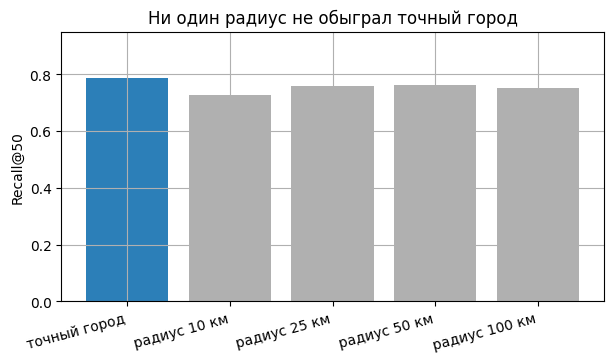

,вариант,recall@50
0,точный город,0.787041
1,радиус 10 км,0.727197
2,радиус 25 км,0.759378
3,радиус 50 км,0.761788
4,радиус 100 км,0.752638


In [51]:
plt.bar(radius_curve["вариант"], radius_curve["recall@50"],
        color=["#2c7fb8"] + ["#b0b0b0"] * 4)
plt.ylabel("Recall@50")
plt.title("Ни один радиус не обыграл точный город")
plt.xticks(rotation=15, ha="right")
plt.ylim(0, 0.95)
plt.show()
radius_curve

логика та же, что с резервом вышла, потому что расширяя круг кандидатов, я добавляю конкурентов на те же
50 мест и теряю местных быстрее, чем нахожу пригородных

в таком случае оставляю простой фильтр по
городу, он и работает лучше, и объясняется проще

## 7. Смысловая близость

хочется улучшить метрику, поэтому думаю в сторону близости, так как может случится вот такая ситуация:

по запросу "перетяжка потолка" человек выбрал объявление "Перешив салона автомобиля в кожу и эко-кожу" общих слов нет вообще, а услуга та же, надо это тоже как то учитывать

для таких случаев беру готовую модель эмбеддингов: она превращает фразу в набор чисел так,
что близкие по смыслу фразы оказываются рядом. Модель маленькая (`multilingual-e5-small`),
знает русский, работает локально. Не дообучаю так как в задании сказано, что ценится воспроизводимость,
а выигрыш, как видно выше, дала не мощность модели, а правильный признак, поэтому берем ее

микро деталь про скорость: по умолчанию модель читает до 512 токенов и тратит на наш корпус
около 50 минут. Смысл услуги умещается в заголовок, поэтому ограничиваю вход 64 токенами, за счёт этого сокращается до 4 минут без потери качества

я думаю ни у кого нет желания сидеть и ждать :)

In [52]:
import torch
from sentence_transformers import SentenceTransformer

def encode_texts(texts, prefix, cache_path, model_name="intfloat/multilingual-e5-small", batch_size=256, max_seq_length=64):
    # векторы текстов готовой моделью. Результат кэшируется на диск
    # модели семейства E5 нужна пометка роли текста "query: " для запроса и "passage: "
    # для документа — так их обучали, без пометок качество заметно падает.

    if cache_path.exists():
        return np.load(cache_path)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")   # ускоряемся!
    model = SentenceTransformer(model_name, device=device)
    model.max_seq_length = max_seq_length

    embeddings = model.encode([prefix + text for text in texts], batch_size=batch_size,
                              normalize_embeddings=True,   # чтобы косинус = скалярное произведение
                              convert_to_numpy=True, show_progress_bar=True).astype(np.float32)
    np.save(cache_path, embeddings)
    return embeddings

здесь будет опять долго

In [53]:
t = time.time()
item_emb = encode_texts(item_texts.tolist(), "passage: ", CACHE / "val_item_emb.npy")
query_emb = encode_texts(query_texts.tolist(), "query: ", CACHE / "val_query_emb.npy")
log(f"эмбеддинги: корпус {item_emb.shape}, запросы {query_emb.shape}", t)

Batches: 100%|██████████| 10/10 [00:02<00:00,  3.56it/s]

эмбеддинги: корпус (189212, 384), запросы (2452, 384)   [498 с]


In [54]:
dense_scorer = lambda row, idx: item_emb[idx] @ query_emb[row]

t = time.time()
final_scores = {}
for name, scorers in {"буквы": [char_scorer], "смысл": [dense_scorer],
                      "буквы + смысл": [char_scorer, dense_scorer]}.items():
    ranked = search_geo_first(scorers, want_loc, loc_index, item_ids, global_candidates)
    final_scores[name] = recall_at_k(to_predictions(query_ids, ranked), truth)
    print(f"{name:16} Recall@50 = {final_scores[name]:.4f}")

буквы            Recall@50 = 0.7870
смысл            Recall@50 = 0.7875
буквы + смысл    Recall@50 = 0.8065


In [55]:
gain = final_scores["буквы + смысл"] - final_scores["буквы"]
print(f"\nприрост от эмбеддингов: {gain * 100:+.2f} процентных пункта")
log("замер готов", t)


прирост от эмбеддингов: +1.95 процентных пункта
замер готов   [89 с]


почти два процента плюсом при том, что по отдельности буквы и смысл дают одинаково

значит они ошибаются на разных запросах и дополняют друг друга. Объединяю их через RRF

словный TF-IDF внутри города я проверила тоже — он давал разницу в пределах шума, поэтому в финальную схему не попал, так как засорять ноутбук не хочется

глобально я его добавила

## 8. Итоговая схема и насколько ей можно верить

```
для каждого запроса:
    кандидаты = объявления в городе запроса
    ранжирую: символьный TF-IDF + эмбеддинги, объединение через RRF
    если местных меньше 50 (или города нет в корпусе) — добираю глобальным поиском
    беру 50
```

обучаемых компонентов нет, так как модель эмбеддингов взята готовой. обучающие данные я использовала не для обучения как такого, а для проверки и для одного вывода — что решает география

In [56]:
best_ranked = search_geo_first([char_scorer, dense_scorer], want_loc, loc_index,
                               item_ids, global_candidates)
best_preds = to_predictions(query_ids, best_ranked)
best = recall_at_k(best_preds, truth)

summary = pd.DataFrame([
    {"шаг": "1. текст", "recall@50": text_scores["буквы + слова"]},
    {"шаг": "2. внутри города", "recall@50": geo_score},
    {"шаг": "3. + смысл", "recall@50": best},
])

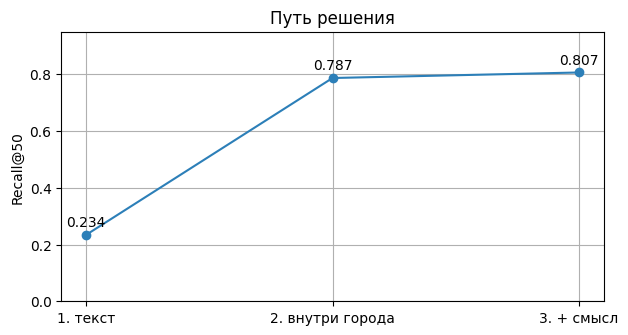

,шаг,recall@50
0,1. текст,0.233672
1,2. внутри города,0.787041
2,3. + смысл,0.806526


In [57]:
plt.plot(summary["шаг"], summary["recall@50"], marker="o", color="#2c7fb8")
plt.ylabel("Recall@50")
plt.title("Путь решения")
plt.ylim(0, 0.95)
for i, v in enumerate(summary["recall@50"]):
    plt.text(i, v + 0.03, f"{v:.3f}", ha="center")
plt.show()
summary

привычная кривая обучения здесь неприменима так как модель ничему не учится

но зато уместен другой вопрос — насколько устойчива сама оценка, посчитанная на 2.5к запросах

проверю это бутстрапом: многократно пересобираю выборку запросов с возвращением и смотрю разброс

In [58]:
rng = np.random.default_rng(0)
per_query_recall = np.array([len(set(best_preds.get(qid, [])) & rel) / len(rel)
                             for qid, rel in truth.items() if rel])
boot = [rng.choice(per_query_recall, size=len(per_query_recall), replace=True).mean()
        for _ in range(1000)]
low, high = np.percentile(boot, [2.5, 97.5])

In [59]:
print(f"Recall@50 = {per_query_recall.mean():.4f}, 95% интервал [{low:.4f}, {high:.4f}]")
print(f"то есть +- {100 * (high - low) / 2:.1f} процентов")

Recall@50 = 0.8065, 95% интервал [0.7912, 0.8210]
то есть +- 1.5 процентов


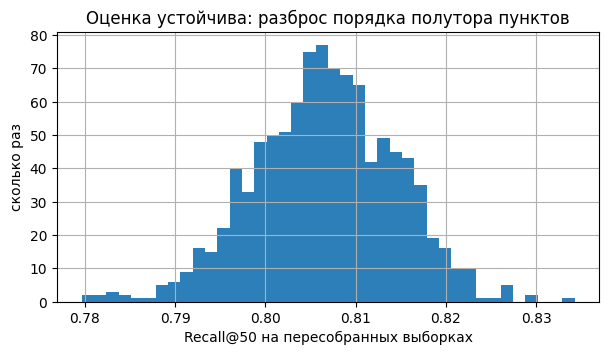

In [60]:
plt.hist(boot, bins=40, color="#2c7fb8")
plt.xlabel("Recall@50 на пересобранных выборках")
plt.ylabel("сколько раз")
plt.title("Оценка устойчива: разброс порядка полутора пунктов")
plt.show()

разброс порядка полутора процентов

отсюда практическое правило, которым я пользовалась выше, что различия меньше этой величины улучшением не считаю

## 9. Собираю ответ на настоящих данных

все то же самое, но корпус и запросы теперь из бенчмарка. Гиперпараметры те, что выбраны
выше: символьные n-граммы 3–5, 200 символов описания, эмбеддинги с ограничением в 64 токена,
резерв под иногородних нулевой.

In [70]:
t0 = time.time()
bench_item_texts = build_item_text(bench_items)
bench_query_texts = build_query_text(bench_queries)
bench_item_ids = bench_items["item_id"].to_numpy()
bench_want_loc = bench_queries["search_location_id"].to_numpy()

In [71]:
ниже долго каждая ячейка будет)

SyntaxError: unmatched ')' (1731142598.py, line 1)

In [ ]:
t = time.time()
b_char_items, b_char_queries = lexical_matrices(
    bench_item_texts, bench_query_texts, "char_wb", (3, 5), 5, "bench_char")
b_word_items, b_word_queries = lexical_matrices(
    bench_item_texts, bench_query_texts, "word", (1, 2), 2, "bench_word")
log("лексические индексы бенчмарка готовы", t)

лексические индексы бенчмарка готовы   [181 с]


In [ ]:
t = time.time()
b_item_emb = encode_texts(bench_item_texts.tolist(), "passage: ", CACHE / "bench_item_emb.npy")
b_query_emb = encode_texts(bench_query_texts.tolist(), "query: ", CACHE / "bench_query_emb.npy")
log(f"эмбеддинги бенчмарка готовы: {b_item_emb.shape}", t)

Batches: 100%|██████████| 10/10 [00:02<00:00,  4.34it/s]

эмбеддинги бенчмарка готовы: (189212, 384)   [512 с]


In [ ]:
t = time.time()
b_loc_ids = bench_items["item_location_id"].to_numpy()
b_loc_index = {loc: np.where(b_loc_ids == loc)[0] for loc in np.unique(bench_want_loc)}
have_local = np.mean([len(b_loc_index.get(loc, [])) > 0 for loc in bench_want_loc])
log(f"запросов, для которых в корпусе есть их город: {have_local:.1%}")

запросов, для которых в корпусе есть их город: 82.6%


In [ ]:
# Глобальный поиск — план Б для остальных если недобралось
b_char_top, _ = topk_by_cosine(b_char_queries, b_char_items, bench_item_ids, k=300)
b_word_top, _ = topk_by_cosine(b_word_queries, b_word_items, bench_item_ids, k=300)

def b_dense_top():
    # топ-300 по смыслу: плотные векторы, поэтому считаю умножением батчами
    k, batch = 300, 256
    out = np.empty((len(bench_queries), k), dtype=object)
    for start in range(0, len(bench_queries), batch):
        stop = min(start + batch, len(bench_queries))
        sims = b_query_emb[start:stop] @ b_item_emb.T
        part = np.argpartition(-sims, kth=k - 1, axis=1)[:, :k]
        rows = np.arange(stop - start)[:, None]
        order = np.argsort(-sims[rows, part], axis=1)
        out[start:stop] = bench_item_ids[part[rows, order]]
    return out

b_global = rrf_fuse([b_dense_top(), b_char_top, b_word_top], k=100)
log("глобальные кандидаты готовы", t)

глобальные кандидаты готовы   [57 с]


In [ ]:
t = time.time()
b_char_scorer = lambda row, idx: np.asarray((b_char_queries[row] @ b_char_items[idx].T).todense()).ravel()
b_dense_scorer = lambda row, idx: b_item_emb[idx] @ b_query_emb[row]
bench_ranked = search_geo_first([b_char_scorer, b_dense_scorer], bench_want_loc, b_loc_index, bench_item_ids, b_global, k=50, reserve_global=0)
log("кандидаты отобраны", t)

кандидаты отобраны   [91 с]


In [ ]:
predictions = {bench_queries["query_id"].iloc[row]: [i for i in bench_ranked[row] if i is not None] for row in range(len(bench_queries))}
answer = pd.DataFrame({"query_id": list(predictions.keys()),
                       "answer": [" ".join(items) for items in predictions.values()]})
answer.to_csv("/Users/ula/Desktop/avito/dataset_avito/answer.csv", index=False)   # index=False обязателен так как лишняя колонка ломает проверку
log(f"записан answer.csv: {len(answer):,} строк", t0)
answer.head(3)

записан answer.csv: 2,452 строк   [1317 с]


,query_id,answer
0,70DfDUpwjxB4lzFd,d722bcda1a555091 603623b4bd9e8f6c 255fbeaf526a1cc1 6042f...
1,JTrdTaZJvSiLPkXj,413f6384e3c07b64 4a435cc0a254c1fd 422d3ffdd5bbf626 8703b...
2,LZCZNoVG4AFUkVRJ,3f89b8062dc85f1c d8fce513e4f000a7 dab52187b4500d9b 168a9...


## 10. Что бы я делала дальше

- **Иногородние 20%** — основной оставшийся потолок. В лоб (резерв, радиус) не берётся, но
  можно решать за запрос: для редких услуг («реставрация роялей») расширять географию,
  для массовых («маникюр») — нет.
- **Микрокатегория.** В корпусе 752 подкатегории; по обучающим данным можно связать слова
  запроса с подкатегорией и получить второй осмысленный фильтр вдобавок к городу.
- **Ранжирование внутри города.** Recall@10 заметно ниже Recall@50 — порядок ещё есть куда
  улучшать, например добавив популярность исполнителя.
- **Порог на глобальный добор.** Сейчас он включается по нехватке местных; можно включать
  и по низкой уверенности текстового совпадения.


спасибо за прочтение моего файлика, я была рада стараться на благо партии ♡

хорошего дня ♡

![название](https://i.pinimg.com/736x/ef/74/d4/ef74d46ada802204d79abfb8489201c3.jpg)

